In [20]:
import numpy as np 
import matplotlib.pyplot as plt

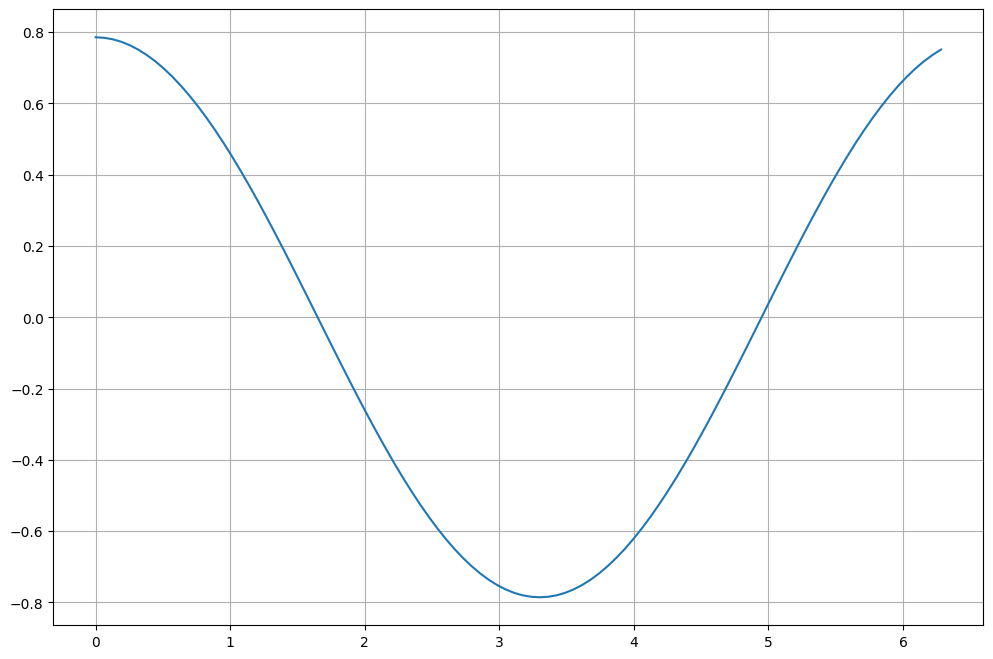

In [22]:
n = 100 
tf = 2*np.pi
h = tf / n
theta = np.zeros(n)
a = np.pi/4
theta[0] = a
theta[1] = a +  h**2 * (-np.sin(a))/2 #funcao horaria da posicao com v0 = 0
plot = np.linspace(0, tf, n)


for i in range(1, n-1):
    theta[i+1] = 2*theta[i] - theta[i-1] + h**2 * (-np.sin(theta[i]))

plt.figure(figsize=(12,8))
plt.plot(plot, theta)
plt.grid(True)
plt.show()


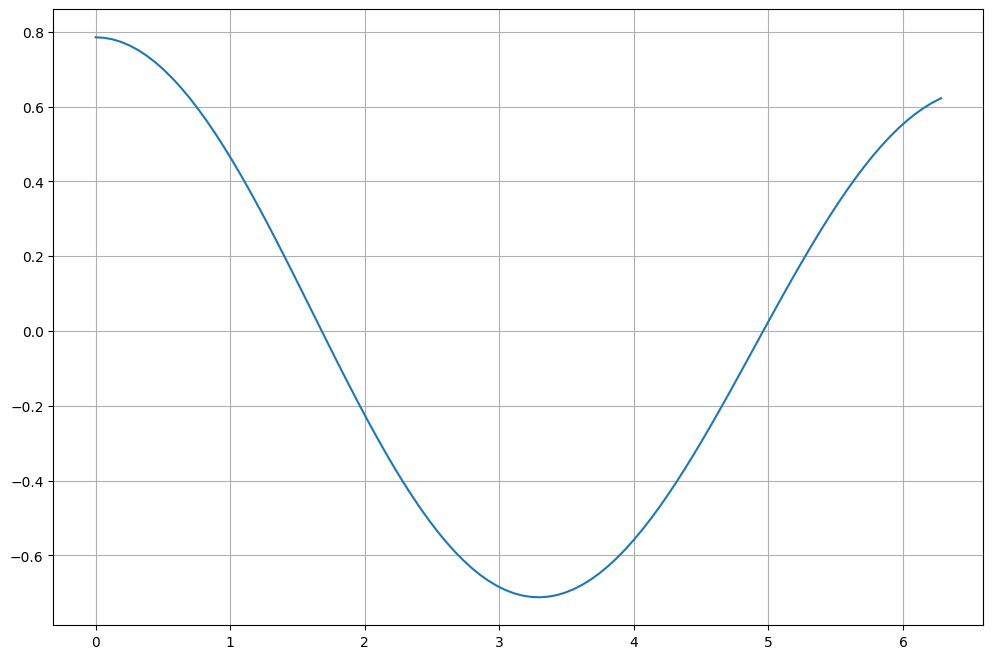

In [27]:
n = 100 
tf = 2*np.pi 
h = tf / n
theta = np.zeros(n)
a = np.pi/4
theta[0] = a
theta[1] = theta[0] + (h**2)*(-np.sin(theta[0]))/2

plot = np.linspace(0, tf, n)

tol = 1e-6

maxit = 10 
for i in range(1, n-1):
    k = 2*theta[i] - theta[i-1]
    x = k

    for j in range(maxit):
        f = x + (h**2) * np.sin(x) - k  
        df = 1 + (h**2) * np.cos(x)
        x = x - (f/df)
        
        if abs(f) < tol:
            break    
    
    theta[i+1] = x


plt.figure(figsize=(12,8))
plt.plot(plot, theta)
plt.grid(True)
plt.show()
    

In [28]:
# theta''(t)  =  -sen(theta(t))
#theta(0) = alpha
#theta(T) = beta
# non linear boundary value problem

# G = ((theta[i-1] - 2theta[i] + theta[i+1]) / h^2) + sen(theta[i]) = 0

# G(Theta) = 0

# 0 = G(Theta^k) + G'(Theta^k)(Theta^(k+1) - Theta^k)

#theta[k+1] = theta[k] + delta[k]

#delta[k] * J[theta[k]] = - G(Theta[k]) 

#J - matriz tridiagonal com elementos diagonais principais J[i,i] = -2/h^2 + cos(theta[i]) e elementos diagonais secundarias J[i,i-1] = J[i,i+1] = 1 multiplicado por 1/h^2 (matriz toda) 

# T = 2pi 
# alpha = beta = 0.7

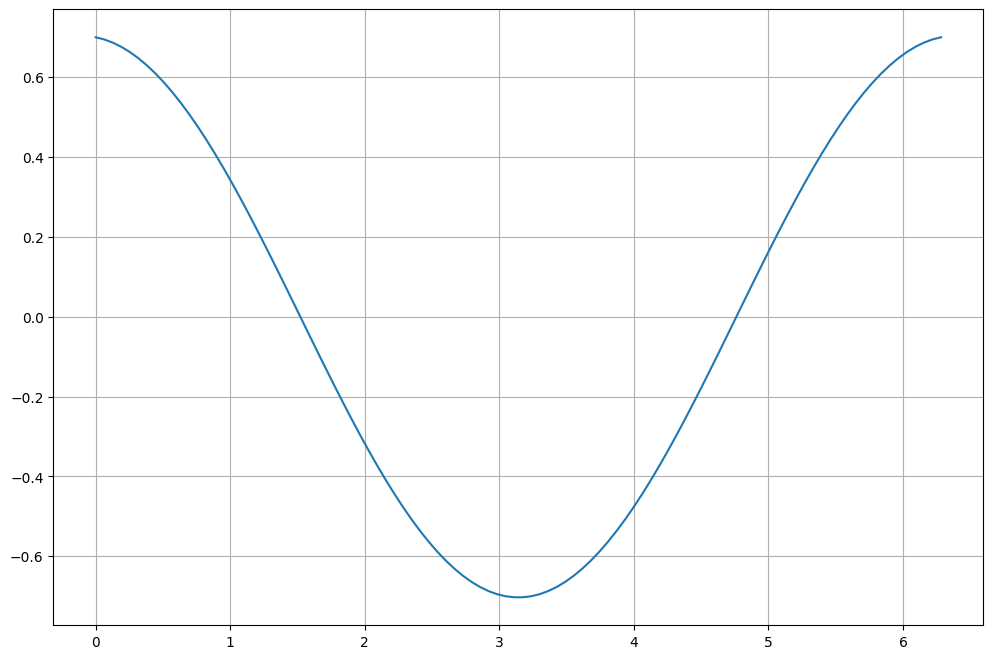

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def montaMatriz(theta, n, h):
    M = np.zeros((n-2, n-2))
    for i in range(n-2):
        for j in range(n-2):
            if i == j:
                M[i][j] = -2.0 +h**2 * np.cos(theta[i+1])
            elif (j == i+1) or (j == i-1): 
                M[i][j] = 1.0
    return (1/h**2)*M






n = 100 
# theta = np.linspace(0.7, 0.7, n)
theta = np.zeros(n)

#boundary conditions
theta[0] = 0.7
theta[-1] = 0.7

tf = 2.0 * np.pi 
h = tf / (n - 1)


maxit = 10 


for k in range(maxit):
    
    G = np.zeros(n-2)
    for i in range(1, n-1):
        G[i-1] = (theta[i-1] - 2*theta[i] + theta[i+1]) / h**2 + np.sin(theta[i])
    
    M = montaMatriz(theta, n, h)
    delta = np.linalg.solve(M, -G)
     
    for i in range(n-2):
        theta[i+1] += delta[i]
    

xplot = np.linspace(0, tf, n)
plt.figure(figsize=(12,8))
plt.plot(xplot, theta)
plt.grid(True)
plt.show()


#matriz esparça , numpy ou array
#algoritmo de thomas para a solução do sistema
